Torch accuracy: 0.900
Sklearn accuracy: 0.900


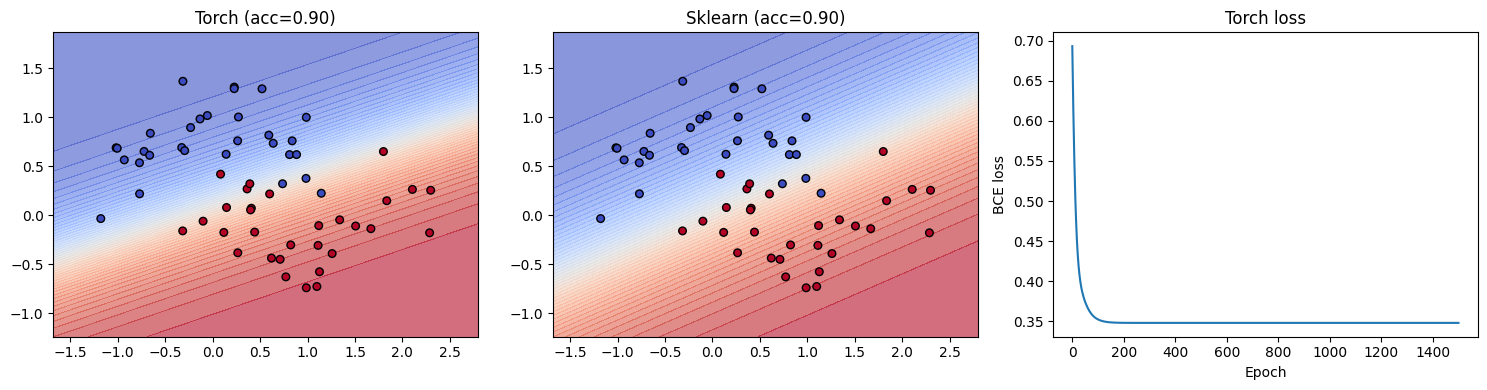

In [2]:
# Logistic Regression from scratch in PyTorch vs scikit-learn on make_moons
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

class LogisticTorch:
    def __init__(self, lr=0.01, epochs=1000, device=None):
        self.lr = lr
        self.epochs = epochs
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.w = None
        self.b = None
        self.loss_curve_ = []

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device).view(-1, 1)
        n_features = X.shape[1]
        self.w = nn.Parameter(torch.zeros(n_features, 1, device=self.device))
        self.b = nn.Parameter(torch.zeros(1, device=self.device))
        optimizer = optim.Adam([self.w, self.b], lr=self.lr)
        criterion = nn.BCEWithLogitsLoss()
        self.loss_curve_.clear()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            logits = X @ self.w + self.b
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            self.loss_curve_.append(loss.item())
        return self

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            logits = X @ self.w + self.b
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
        return np.c_[1 - probs, probs]

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# Data
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Train torch model
torch.manual_seed(0)
lt = LogisticTorch(lr=0.05, epochs=1500).fit(X_train, y_train)
y_pred_t = lt.predict(X_test)
acc_t = accuracy_score(y_test, y_pred_t)

# Train sklearn model
sk = LogisticRegression().fit(X_train, y_train)
y_pred_sk = sk.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)

print(f"Torch accuracy: {acc_t:.3f}")
print(f"Sklearn accuracy: {acc_sk:.3f}")

# Decision boundary helper
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model(grid)
    Z = zz.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.6)
    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
plot_decision_boundary(axes[0], lambda x: lt.predict_proba(x)[:,1], X_test, y_test,
                       f"Torch (acc={acc_t:.2f})")
plot_decision_boundary(axes[1], lambda x: sk.predict_proba(x)[:,1], X_test, y_test,
                       f"Sklearn (acc={acc_sk:.2f})")
axes[2].plot(lt.loss_curve_)
axes[2].set_title("Torch loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("BCE loss")
plt.tight_layout()
plt.show()

Epoch 100/1000, loss=0.4062
Epoch 200/1000, loss=0.3614
Epoch 300/1000, loss=0.3431
Epoch 400/1000, loss=0.3330
Epoch 500/1000, loss=0.3267
Epoch 600/1000, loss=0.3224
Epoch 700/1000, loss=0.3195
Epoch 800/1000, loss=0.3174
Epoch 900/1000, loss=0.3159
Epoch 1000/1000, loss=0.3148

Accuracy (LogisticTorch): 0.850
Accuracy (sklearn LogisticRegression): 0.850


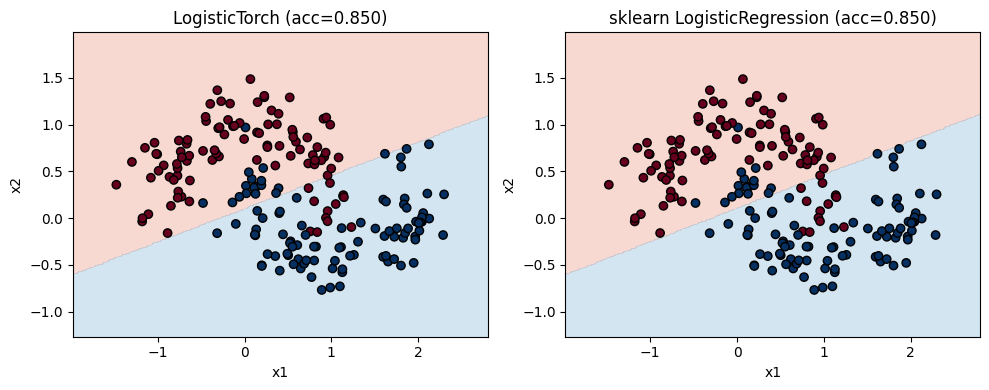

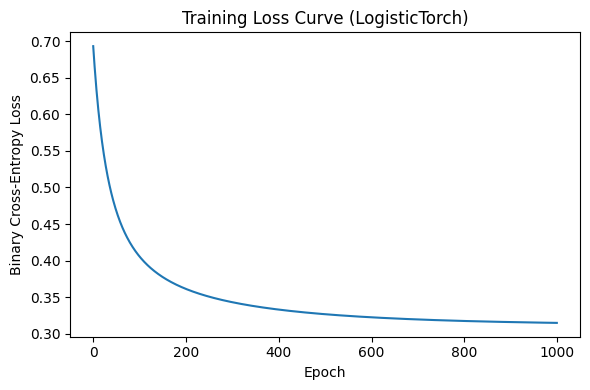

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Our LogisticTorch class
# -------------------------
class LogisticTorch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        """
        X: numpy array (n_samples, n_features)
        y: numpy array (n_samples,) with labels 0/1
        """
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        n_samples, n_features = X.shape

        # Convert to torch tensors
        X_t = torch.from_numpy(X)              # (N, D)
        y_t = torch.from_numpy(y)              # (N,)

        # Initialize parameters
        self.w = torch.zeros(n_features, 1, requires_grad=True)  # (D,1)
        self.b = torch.zeros(1, requires_grad=True)              # (1,)

        optimizer = torch.optim.SGD([self.w, self.b], lr=self.lr)

        self.loss_history = []

        for epoch in range(self.epochs):
            optimizer.zero_grad()

            # Linear part: (N,D) @ (D,1) -> (N,1)
            logits = X_t @ self.w + self.b     # (N,1)
            logits = logits.squeeze()          # (N,)

            # Binary cross entropy with logits is numerically stable
            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            loss.backward()
            optimizer.step()

            self.loss_history.append(loss.item())

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, loss={loss.item():.4f}")

    def predict_proba(self, X):
        """
        Returns probability of class 1 for each sample.
        X: numpy array (n_samples, n_features)
        """
        if self.w is None:
            raise RuntimeError("Model is not fitted yet.")

        X = np.asarray(X, dtype=np.float32)
        X_t = torch.from_numpy(X)

        with torch.no_grad():
            logits = X_t @ self.w + self.b      # (N,1)
            probs = torch.sigmoid(logits).squeeze()  # (N,)
        return probs.numpy()

    def predict(self, X):
        """
        Returns predicted class labels (0 or 1).
        """
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)


# -------------------------
# 2. Generate dataset
# -------------------------
np.random.seed(42)
torch.manual_seed(42)

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# -------------------------
# 3. Train our LogisticTorch
# -------------------------
model_torch = LogisticTorch(lr=0.1, epochs=1000)
model_torch.fit(X, y)

y_pred_torch = model_torch.predict(X)
acc_torch = accuracy_score(y, y_pred_torch)
print(f"\nAccuracy (LogisticTorch): {acc_torch:.3f}")

# -------------------------
# 4. Train sklearn LogisticRegression
# -------------------------
model_sklearn = LogisticRegression()
model_sklearn.fit(X, y)

y_pred_sklearn = model_sklearn.predict(X)
acc_sklearn = accuracy_score(y, y_pred_sklearn)
print(f"Accuracy (sklearn LogisticRegression): {acc_sklearn:.3f}")


# -------------------------
# 5. Helper: decision boundary plot
# -------------------------
def plot_decision_boundary(pred_fn, X, y, title):
    # Set up grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]  # (Ngrid, 2)
    Z = pred_fn(grid)                     # predicted labels
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.1, 0.5, 1.1], cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")


# -------------------------
# 6. Plot decision boundaries
# -------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_decision_boundary(lambda X_grid: model_torch.predict(X_grid),
                       X, y,
                       f"LogisticTorch (acc={acc_torch:.3f})")

plt.subplot(1, 2, 2)
plot_decision_boundary(lambda X_grid: model_sklearn.predict(X_grid),
                       X, y,
                       f"sklearn LogisticRegression (acc={acc_sklearn:.3f})")

plt.tight_layout()
plt.show()


# -------------------------
# 7. Plot loss curve for LogisticTorch
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(model_torch.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Curve (LogisticTorch)")
plt.tight_layout()
plt.show()
